# Label transfer / projection on simulated cluster dataset

In this notebook, we demonstrate how to use CONCORD in classification mode to transfer labels from one dataset to another. As an example, we'll work with a simulated single-batch dataset containing 3 clusters. You can apply the same pipeline to multi-batch datasets simply by providing the `domain_key` parameter when running CONCORD.

### Package loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import scanpy as sc
import time
from pathlib import Path
import torch
import concord as ccd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
import matplotlib as mpl

from matplotlib import font_manager, rcParams
custom_rc = {
    'font.family': 'Arial',  # Set the desired font for this plot
}

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['pdf.fonttype'] = 42

In [3]:
proj_name = "simulation_clustereasy_classification"
save_dir = f"../save/dev_{proj_name}-{time.strftime('%b%d')}/"
save_dir = Path(save_dir)
save_dir.mkdir(parents=True, exist_ok=True)

data_dir = f"../data/{proj_name}/"
data_dir = Path(data_dir)
data_dir.mkdir(parents=True, exist_ok=True)
device = torch.device('cuda:3' if torch.cuda.is_available() else 'cpu')
print(device)
seed = 0
ccd.ul.set_seed(seed)

file_suffix = f"{time.strftime('%b%d-%H%M')}"
file_suffix

cpu


'Oct15-2026'

### Simulate simple 3-cluster dataset

In [4]:
state_key = 'cluster'
batch_key = 'batch'
state_type = 'cluster'
leiden_key='leiden'
batch_type = 'batch_specific_features'
distribution = 'normal'

In [5]:
from concord.simulation import (
    SimConfig, ClusterConfig, BatchConfig, Simulation
)

# ──────────────── Inputs ────────────────
seed = 42
n_cells = [100,100,50]
n_genes = [1000,1000,500]
state_dispersion = [4.0, 2.0, 2.0]

# ─────────────── SimConfig ───────────────
sim_cfg = SimConfig(
    n_cells=n_cells,
    n_genes=n_genes,
    seed=seed,
    non_neg=True,
    to_int=True,
)

# ─────────────── ClusterConfig ───────────────
state_cfg = ClusterConfig(
    n_states=3,
    distribution="normal",
    level=5.0,
    min_level=0.0,
    dispersion=state_dispersion,
    program_structure="uniform",
    program_on_time_fraction=0.3,
    global_non_specific_gene_fraction=0.1,
    pairwise_non_specific_gene_fraction=None,
)

# ─────────────── BatchConfig ───────────────
batch_cfg = BatchConfig(
    n_batches=1,
    effect_type="batch_specific_features",
    distribution="normal",
    level=[5.0],              # One value for 1 batch
    dispersion=[3.0],
    feature_frac=0.15,
)

# ─────────────── Simulation ───────────────
sim = Simulation(sim_cfg, state_cfg, batch_cfg)
adata, adata_state = sim.simulate_data()
adata.layers["counts"] = adata.X.copy()


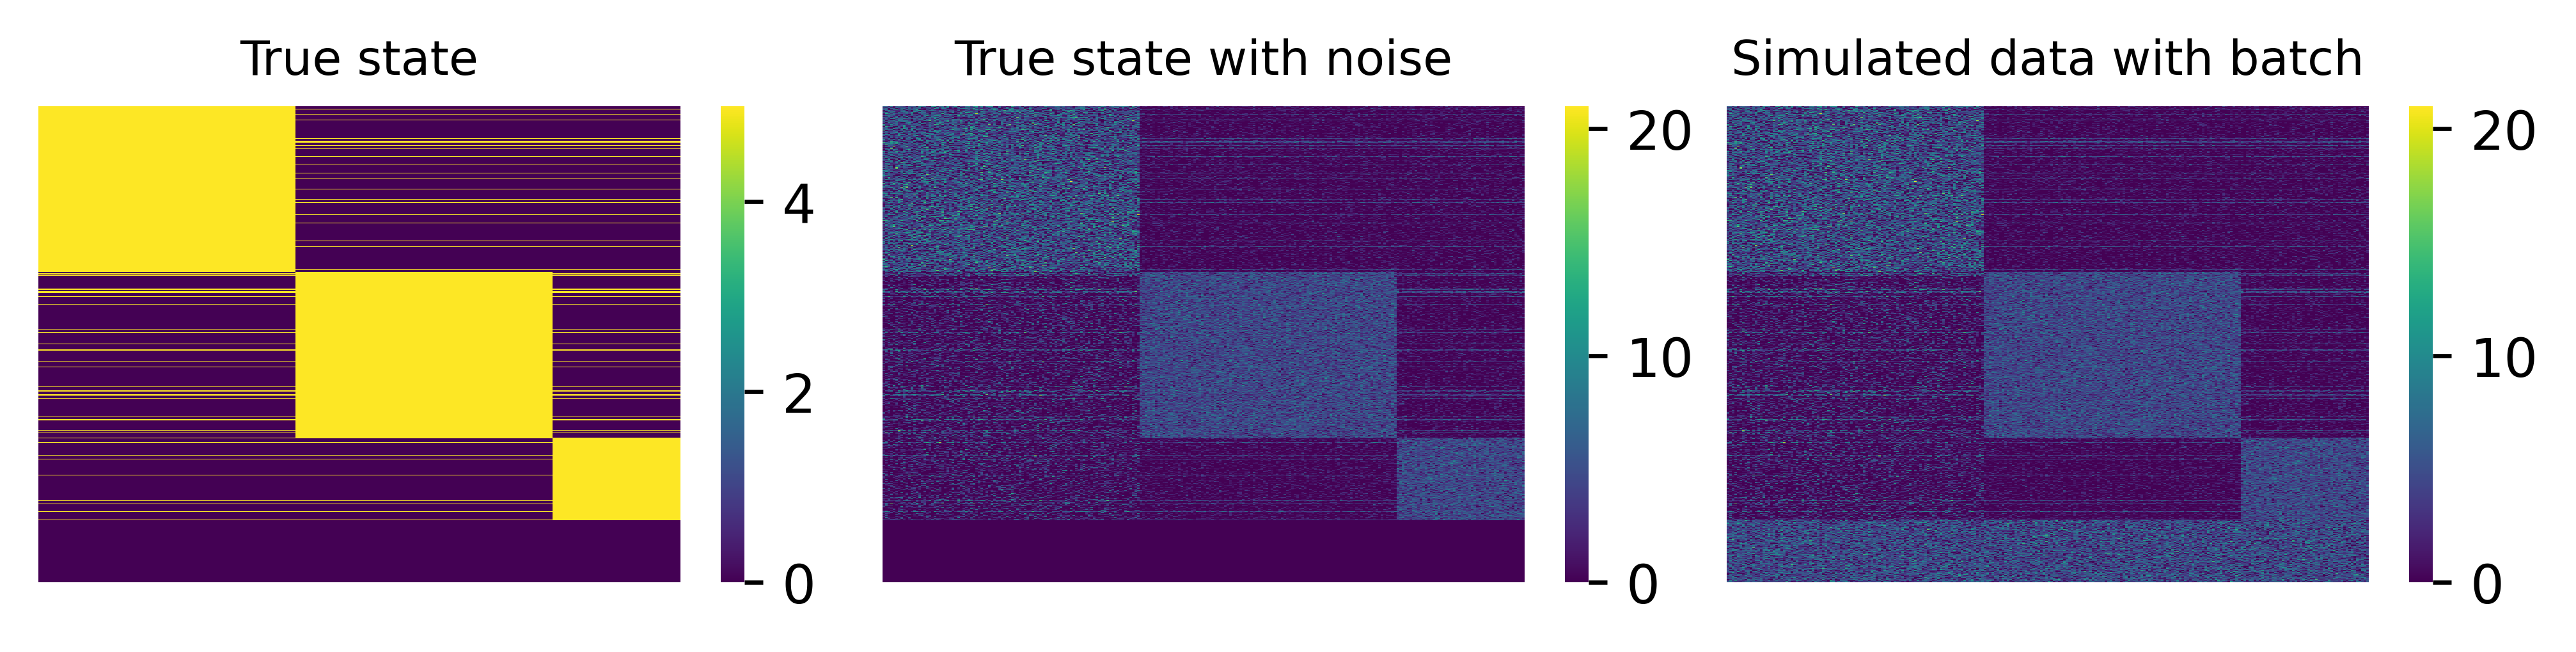

In [6]:
import matplotlib.pyplot as plt
figsize = (2.3, 1.8)
ncols = 3
title_fontsize = 9
dpi = 600
_, _, state_pal = ccd.pl.get_color_mapping(adata, state_key, pal='Paired', seed=seed)
_, _, batch_pal = ccd.pl.get_color_mapping(adata, batch_key, pal='Set1', seed=seed)
pal = {state_key: state_pal, batch_key: batch_pal}
fig, axes = plt.subplots(1, ncols, figsize=(figsize[0] * ncols, figsize[1]), dpi=dpi)
for ax, (val, title) in zip(
        axes,
        [('no_noise', 'True state'),
         ('wt_noise', 'True state with noise'),
         ('X',        'Simulated data with batch')]):

    ccd.pl.heatmap_with_annotations(
        adata,
        val=val,
        obs_keys=[state_key] if val != 'X' else [state_key, batch_key],
        pal=pal,
        use_clustermap=False,        # plain heat‑map
        cluster_rows=False,
        cluster_cols=False,
        yticklabels=False,
        value_annot=False,
        cmap='viridis',
        title=title,
        title_fontsize=9,
        ax=ax,
        show=False                   # don’t flush the figure yet
    )

plt.tight_layout(w_pad=0.0, h_pad=0.1)
plt.savefig(save_dir / f"data_heatmaps_{file_suffix}.svg",
            dpi=600, bbox_inches='tight')
plt.show()

### Run dimension reduction

Let's take a look at the data with standard PCA and UMAP.

In [6]:
n_components = 15
adata.obsm['no_noise'] = adata.layers['no_noise']
adata.obsm['wt_noise'] = adata.layers['wt_noise']
ccd.ul.run_pca(adata, source_key='no_noise', result_key='PCA_no_noise', n_pc=n_components, random_state=seed)
sc.pp.neighbors(adata, use_rep='PCA_no_noise', n_neighbors=30, random_state=seed)
ccd.ul.run_umap(adata, source_key='no_noise', result_key='UMAP_no_noise', random_state=seed)
ccd.ul.run_umap(adata, source_key='wt_noise', result_key='UMAP_wt_noise', random_state=seed)

concord - INFO - PCA performed on source data with 15 components
concord - INFO - PCA embedding stored in adata.obsm['PCA_no_noise']


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


concord - INFO - UMAP embedding stored in adata.obsm['UMAP_no_noise']
concord - INFO - UMAP embedding stored in adata.obsm['UMAP_wt_noise']


In [7]:
# Random set 30% class labels to 'unlabeled' for prediction
adata.obs['input_state'] = adata.obs[state_key].astype(str)
adata.obs['input_state'][adata.obs.sample(frac=0.3, random_state=seed).index] = 'unlabeled'
adata.obs['input_state'].value_counts() 
clus_pal = {
    'unlabeled': 'lightgray',
    'cluster_1': 'red',
    'cluster_2': 'blue',
    'cluster_3': 'green',
}
pal = {'input_state': clus_pal,
       state_key: clus_pal,
       'Concord_class_pred': clus_pal
       }


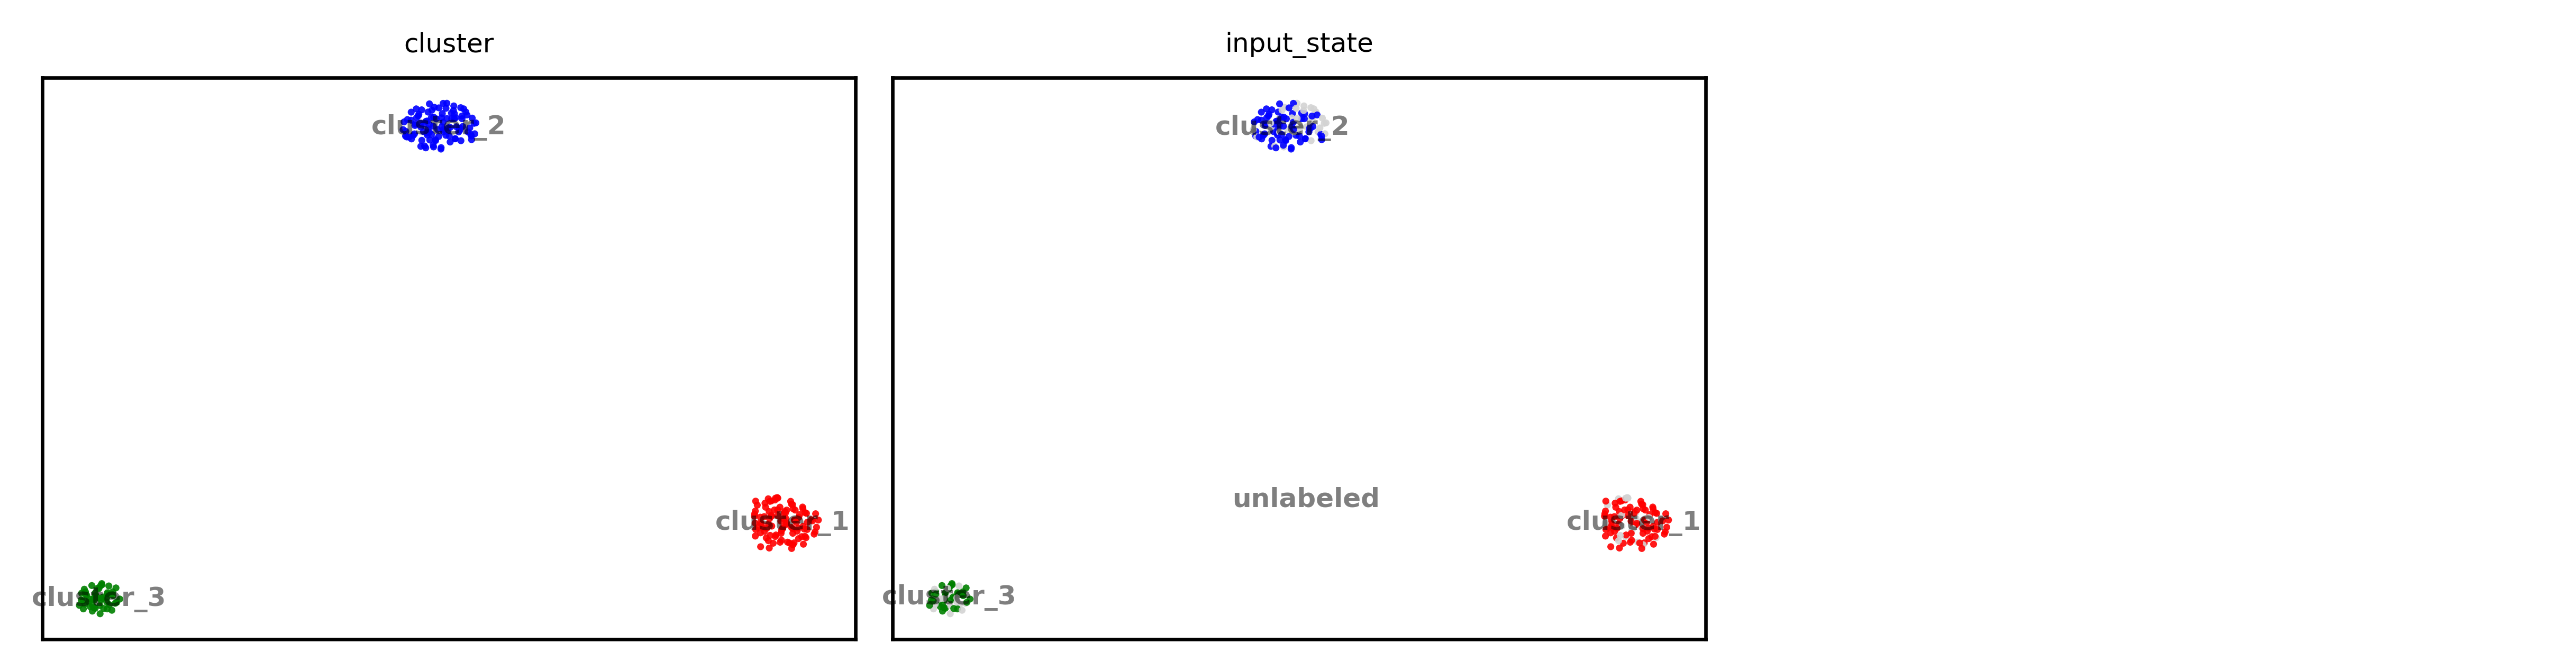

In [8]:
color_by = [state_key, 'input_state'] # Choose which variables you want to visualize
ccd.pl.plot_embedding(
    adata, basis='UMAP_wt_noise', color_by=color_by, figsize=(8, 2), dpi=600, ncols=3, font_size=6, point_size=10, legend_loc='on data',
    pal=pal,
    save_path=save_dir / 'UMAP_wt_noise.png'
)

### Brief intro to CONCORD classification mode

Enable classification by setting `use_classifier=True`.  
To reduce overfitting, we recommend also hold out a validation set (e.g., `train_frac=0.9`).

CONCORD supports three labeling workflows:

1) **Semi-supervised joint training**  
   Train on **all cells**; only labeled cells contribute to the classification loss, while **all cells** participate in learning the manifold (via contrastive objective).  
   *Pros:* leverages unlabeled data for representation learning; labels refine decision boundaries.  
   *Cons:* slightly more tuning may be needed if labels are sparse or imbalanced.

2) **Supervised on labeled-only cells**  
   Train using **only labeled cells** and then predict the rest.  
   *Pros:* simple and often strong when labels are abundant and clean.  
   *Cons:* unlabeled cells do not influence the manifold, which can reduce structure in heterogeneous datasets.

3) **Unsupervised + external classifier**  
   Learn the embedding **without** a classifier (`use_classifier=False`), then fit a third-party classifier (e.g., [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) on labeled cells to annotate the unlabeled set.  
   *Pros:* decouples embedding from the classifier; easy to swap models.  
   *Cons:* ignores labels during representation learning and can yield lower classification performance.


### Strategy 1: Semi-supervised joint training

In [ ]:
# If integrating data across batch, simply add the domain_key argument to indicate the batch key in adata.obs
cur_ccd = ccd.Concord(adata=adata, 
                      class_key = 'input_state',
                      use_classifier = True,
                      unlabeled_class = 'unlabeled',
                      clr_beta=1.0,
                      p_intra_knn=0,
                      n_epochs=10,
                      preload_dense=True, 
                      verbose=True,
                      train_frac=0.9, # Use 90% of data for training, and 10% for validation
                      device=device) 

# Encode data, saving the latent embedding in adata.obsm['Concord']
cur_ccd.fit_transform(output_key='Concord')

concord - INFO - Operating directly on the provided AnnData object. Object may be modified.
concord - WARNING - Input data in adata.X appears to be raw counts. CONCORD performs best on normalized and log-transformed data. Consider setting normalize_total=True and log1p=True.
concord - WARNING - No input feature list provided. It is recommended to first select features using the command `concord.ul.select_features()`.
concord - INFO - Proceeding with all 2875 features in the dataset.
concord - INFO - Using NT-Xent loss with beta=1.0. This will apply hard-negative weighting to the contrastive loss.
concord - INFO - HCL (Contrastive learning with hard negative samples) mode is enabled.
concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.
concord - INFO - Column 'input_state' is already of type: category
concord - INFO - Unused levels dropped for

Epoch 0 Training: 100%|██████████| 1/1 [00:00<00:00, 76.75it/s, loss=6.819]

concord - INFO - Epoch   0 | Train Loss: 6.82, MSE: 0.00, CLASS: 1.18, CONTRAST: 5.63, IMPORTANCE: 0.00
concord - INFO - Epoch:   0 | Train accuracy:  0.41 | precision: 0: 0.42, 1: 0.22, 2: 0.50 | recall: 0: 0.84, 1: 0.05, 2: 0.11 | f1: 0: 0.56, 1: 0.08, 2: 0.17



Epoch 0 Validation: 100%|██████████| 1/1 [00:00<00:00, 336.81it/s, loss=5.341]

concord - INFO - Epoch   0 | Val Loss: 5.34, MSE: 0.00, CLASS: 1.59, CONTRAST: 3.75, IMPORTANCE: 0.00
concord - INFO - Epoch:   0 | Val accuracy:  0.37 | precision: 0: 0.00, 1: 0.37, 2: 0.00 | recall: 0: 0.00, 1: 1.00, 2: 0.00 | f1: 0: 0.00, 1: 0.54, 2: 0.00
concord - INFO - New best model found at epoch 1 with validation loss: 5.3413
concord - INFO - Starting epoch 2/10
concord - INFO - Processing chunk 1/1 for epoch 2
concord - INFO - Number of samples in train_dataloader: 225
concord - INFO - Number of samples in val_dataloader: 25


...


Epoch 9 Training: 100%|██████████| 1/1 [00:00<00:00, 69.30it/s, loss=5.393]

concord - INFO - Epoch   9 | Train Loss: 5.39, MSE: 0.00, CLASS: 0.01, CONTRAST: 5.38, IMPORTANCE: 0.00
concord - INFO - Epoch:   9 | Train accuracy:  1.00 | precision: 0: 1.00, 1: 1.00, 2: 1.00 | recall: 0: 1.00, 1: 1.00, 2: 1.00 | f1: 0: 1.00, 1: 1.00, 2: 1.00



Epoch 9 Validation: 100%|██████████| 1/1 [00:00<00:00, 347.10it/s, loss=3.619]

concord - INFO - Epoch   9 | Val Loss: 3.62, MSE: 0.00, CLASS: 0.01, CONTRAST: 3.61, IMPORTANCE: 0.00
concord - INFO - Epoch:   9 | Val accuracy:  1.00 | precision: 0: 1.00, 1: 1.00, 2: 1.00 | recall: 0: 1.00, 1: 1.00, 2: 1.00 | f1: 0: 1.00, 1: 1.00, 2: 1.00


concord - INFO - New best model found at epoch 10 with validation loss: 3.6190
concord - INFO - Best model state loaded into the model before final save.
concord - INFO - Model saved to save/final_model_Sep10-2134.pt
concord - INFO - Final model saved at: save/final_model_Sep10-2134.pt; Configuration saved at: save/config_Sep10-2134.json.
concord.model.dataloader - INFO - Using 0 DataLoader workers.
concord.model.anndataset - INFO - Initialized lightweight dataset with 250 samples.
concord.model.dataloader - INFO - Loading all data into memory for fast access. This may consume a lot of RAM. If you run out of memory, please set `preload_dense=False`.
concord - INFO - Predicting for chunk 1/1
concord - INFO - Predictions added to AnnData object with base key 'Concord'.


concord - INFO - UMAP embedding stored in adata.obsm['Concord_UMAP']


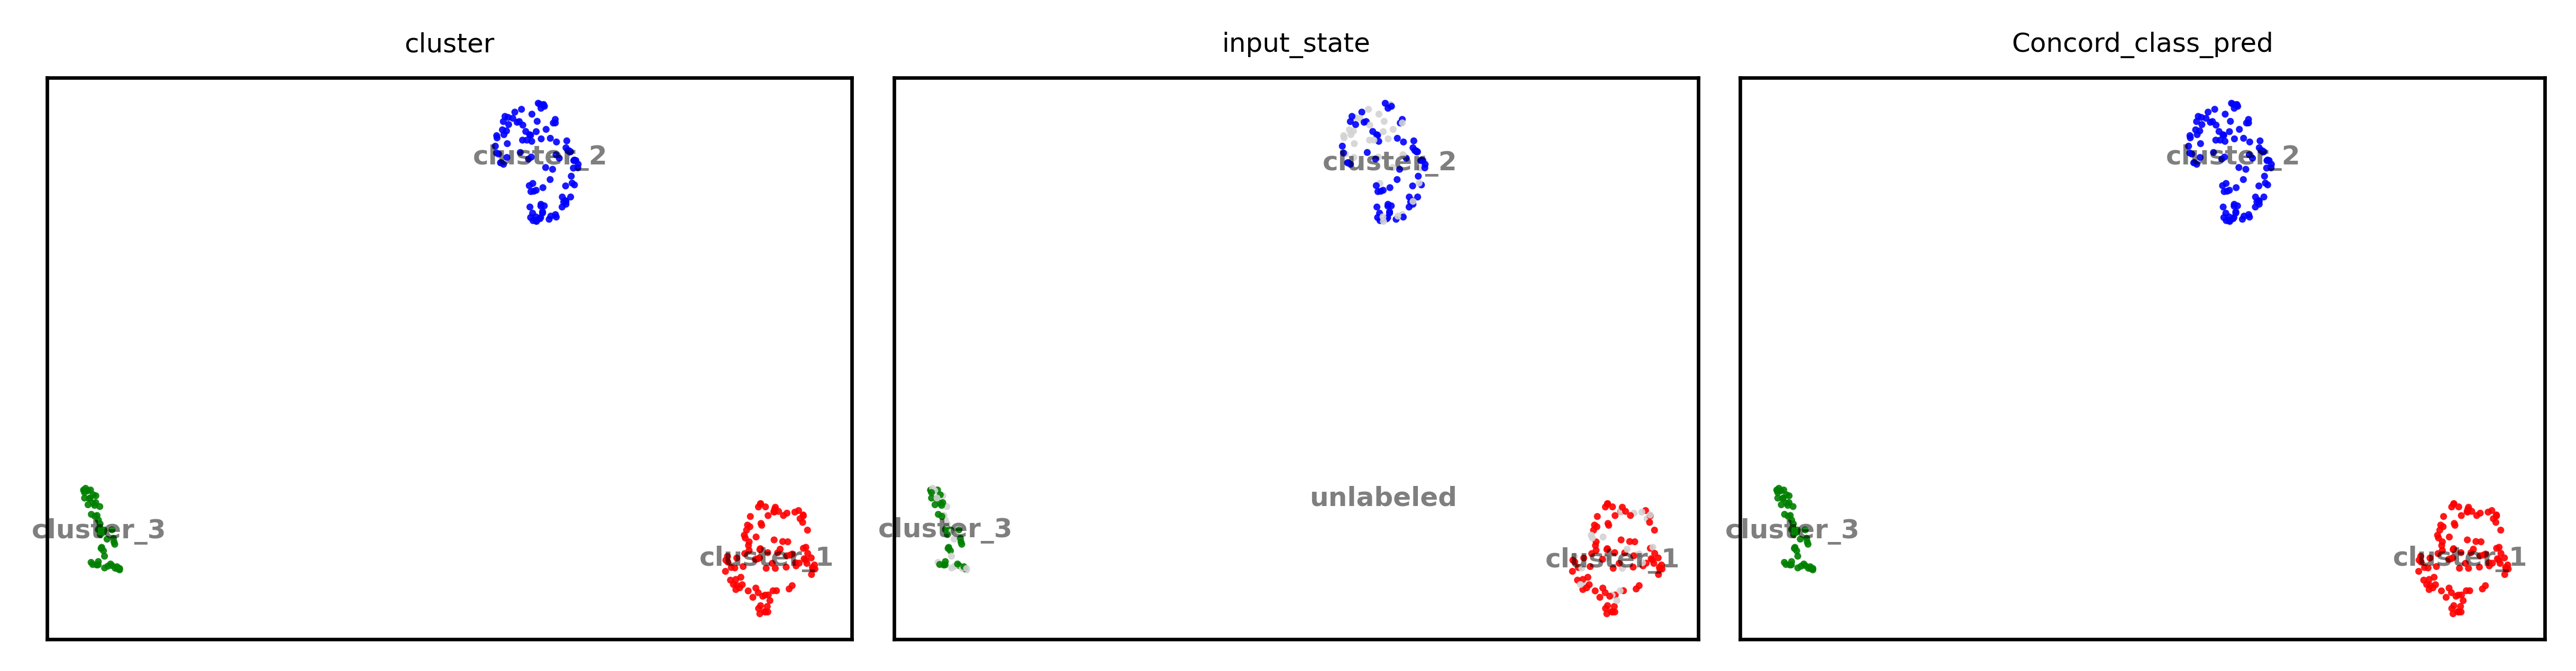

In [13]:
ccd.ul.run_umap(adata, source_key='Concord', result_key='Concord_UMAP', n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine')
color_by = [state_key, 'input_state', 'Concord_class_pred']
ccd.pl.plot_embedding(
    adata, basis='Concord_UMAP', color_by=color_by, figsize=(8, 2), dpi=600, ncols=3, font_size=6, point_size=10, legend_loc='on data',
    pal=pal,
    save_path=save_dir / 'Concord_UMAP.png'
)

### Strategy 2: Supervised training on labeled-only cells

In [14]:
adata_train = adata[adata.obs['input_state'] != 'unlabeled']
adata_pred = adata[adata.obs['input_state'] == 'unlabeled']

The model only sees the labeled dataset during training:

In [15]:
cur_ccd = ccd.Concord(adata=adata_train, 
                      class_key = 'input_state',
                      use_classifier = True,
                      clr_beta=1.0,
                      p_intra_knn=0,
                      n_epochs=10,
                      preload_dense=True, 
                      verbose=True,
                      train_frac=0.9, # Use 90% of data for training, and 10% for validation
                      save_dir=save_dir / 'model/', # directory to save model checkpoints
                      ) 
# Encode data, saving the latent embedding in adata.obsm['Concord']
cur_ccd.fit_transform(output_key='Concord')

concord - INFO - Operating directly on the provided AnnData object. Object may be modified.
concord - WARNING - Input data in adata.X appears to be raw counts. CONCORD performs best on normalized and log-transformed data. Consider setting normalize_total=True and log1p=True.
concord - WARNING - No input feature list provided. It is recommended to first select features using the command `concord.ul.select_features()`.
concord - INFO - Proceeding with all 2875 features in the dataset.
concord - INFO - Using NT-Xent loss with beta=1.0. This will apply hard-negative weighting to the contrastive loss.
concord - INFO - HCL (Contrastive learning with hard negative samples) mode is enabled.
concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.
concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.
concord - INFO - Column 'input_state' is already of type: category
concord - INFO - Unused levels dropped for

Epoch 0 Training: 100%|██████████| 1/1 [00:00<00:00, 88.13it/s, loss=6.761]

concord - INFO - Epoch   0 | Train Loss: 6.76, MSE: 0.00, CLASS: 1.34, CONTRAST: 5.42, IMPORTANCE: 0.00
concord - INFO - Epoch:   0 | Train accuracy:  0.43 | precision: 0: 0.45, 1: 0.33, 2: 0.00 | recall: 0: 0.91, 1: 0.06, 2: 0.00 | f1: 0: 0.60, 1: 0.11, 2: 0.00



Epoch 0 Validation: 100%|██████████| 1/1 [00:00<00:00, 379.95it/s, loss=5.390]

concord - INFO - Epoch   0 | Val Loss: 5.39, MSE: 0.00, CLASS: 2.02, CONTRAST: 3.37, IMPORTANCE: 0.00
concord - INFO - Epoch:   0 | Val accuracy:  0.50 | precision: 0: 0.00, 1: 0.40, 2: 1.00 | recall: 0: 0.00, 1: 1.00, 2: 1.00 | f1: 0: 0.00, 1: 0.57, 2: 1.00
concord - INFO - New best model found at epoch 1 with validation loss: 5.3897
concord - INFO - Starting epoch 2/10
concord - INFO - Processing chunk 1/1 for epoch 2
concord - INFO - Number of samples in train_dataloader: 157
concord - INFO - Number of samples in val_dataloader: 18


...

concord - INFO - Epoch   9 | Train Loss: 5.29, MSE: 0.00, CLASS: 0.01, CONTRAST: 5.27, IMPORTANCE: 0.00


concord - INFO - Epoch:   9 | Train accuracy:  1.00 | precision: 0: 1.00, 1: 1.00, 2: 1.00 | recall: 0: 1.00, 1: 1.00, 2: 1.00 | f1: 0: 1.00, 1: 1.00, 2: 1.00


Epoch 9 Validation: 100%|██████████| 1/1 [00:00<00:00, 182.75it/s, loss=3.288]

concord - INFO - Epoch   9 | Val Loss: 3.29, MSE: 0.00, CLASS: 0.01, CONTRAST: 3.28, IMPORTANCE: 0.00
concord - INFO - Epoch:   9 | Val accuracy:  1.00 | precision: 0: 1.00, 1: 1.00, 2: 1.00 | recall: 0: 1.00, 1: 1.00, 2: 1.00 | f1: 0: 1.00, 1: 1.00, 2: 1.00
concord - INFO - New best model found at epoch 10 with validation loss: 3.2882
concord - INFO - Best model state loaded into the model before final save.


concord - INFO - Model saved to ../save/dev_simulation_clustereasy_classification-Sep10/model/final_model_Sep10-2136.pt
concord - INFO - Final model saved at: ../save/dev_simulation_clustereasy_classification-Sep10/model/final_model_Sep10-2136.pt; Configuration saved at: ../save/dev_simulation_clustereasy_classification-Sep10/model/config_Sep10-2136.json.
concord.model.dataloader - INFO - Using 0 DataLoader workers.
concord.model.anndataset - INFO - Initialized lightweight dataset with 175 samples.
concord.model.dataloader - INFO - Loading all data into memory for fast access. This may consume a lot of RAM. If you run out of memory, please set `preload_dense=False`.
concord - INFO - Predicting for chunk 1/1
concord - INFO - Predictions added to AnnData object with base key 'Concord'.


concord - INFO - UMAP embedding stored in adata.obsm['Concord_UMAP']


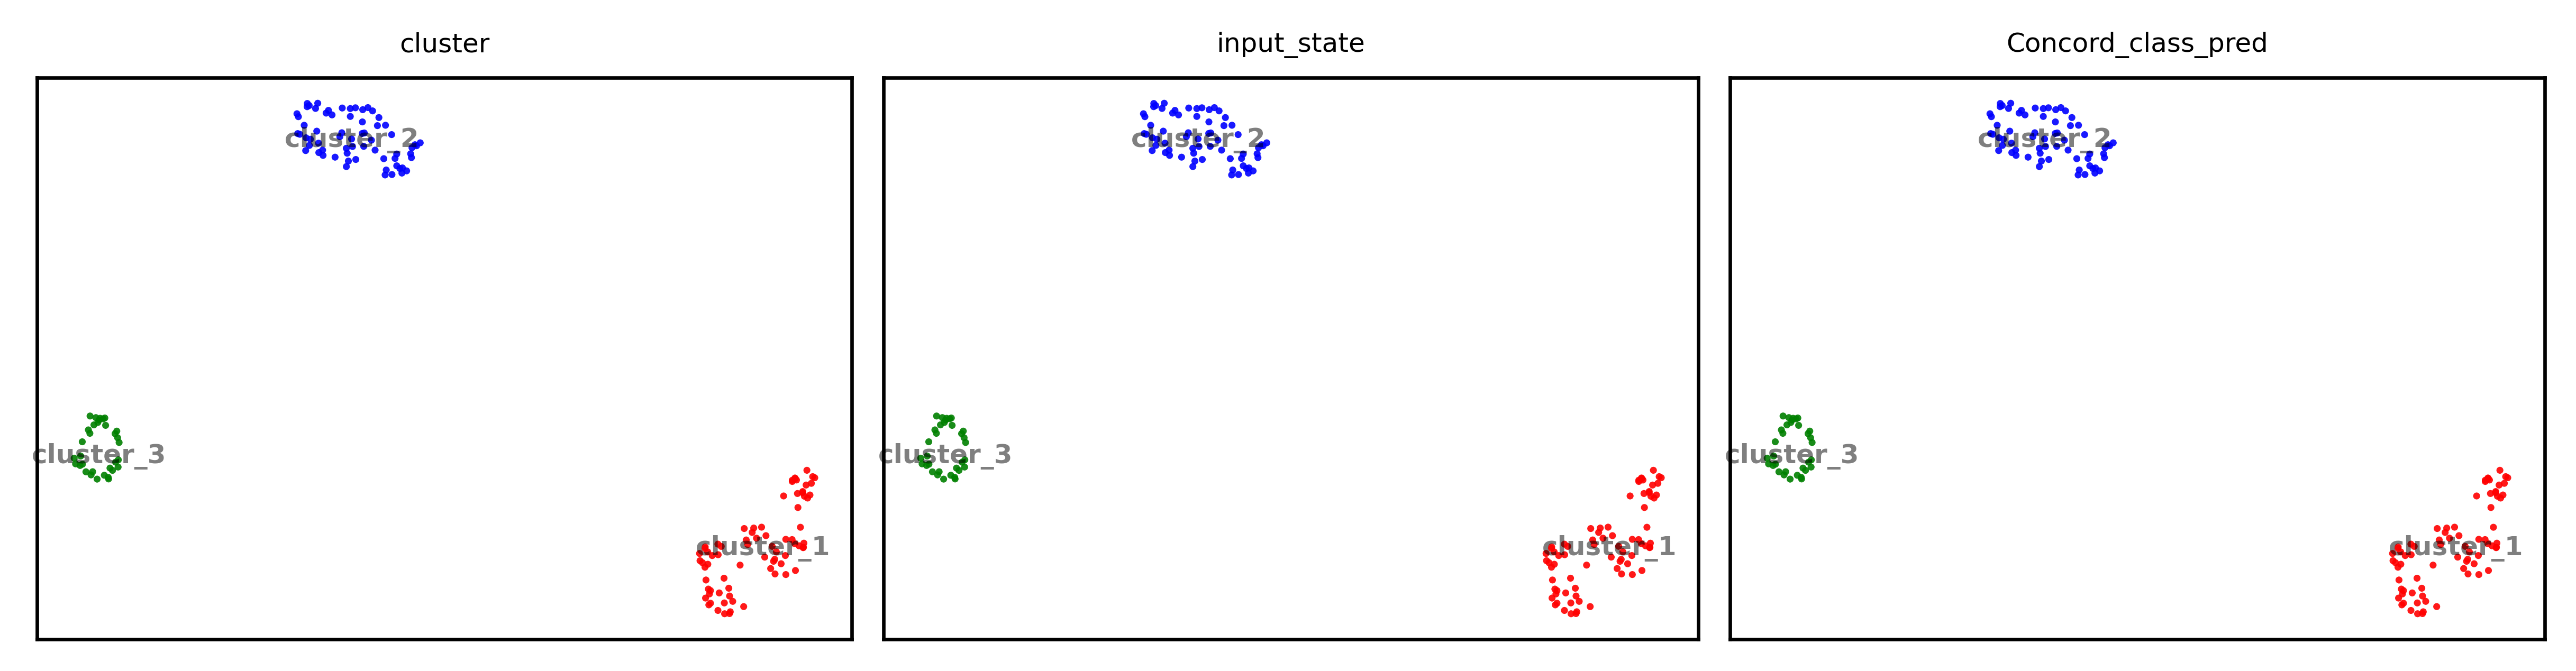

In [16]:
ccd.ul.run_umap(adata_train, source_key='Concord', result_key='Concord_UMAP', n_components=2, n_neighbors=15, min_dist=0.1, metric='cosine')

ccd.pl.plot_embedding(
    adata_train, basis='Concord_UMAP', color_by=color_by, figsize=(8, 2), dpi=600, ncols=3, font_size=6, point_size=10, legend_loc='on data',
    pal=pal,
    save_path=save_dir / 'Concord_UMAP.png'
)

After training, use the snippet below to (optionally) reload the saved model and run inference on held-out or new data. Inference writes **predicted labels** and **per-class probabilities** to `adata.obs`, and **projects** the new cells into the learned latent space via the trained encoder, saving the embedding in `adata.obsm` (keys depend on your chosen `output_key`).

In [17]:
#cur_ccd = ccd.Concord.load(model_dir=save_dir / 'model/',)
cur_ccd.predict_adata(adata_pred, output_key='Concord')

concord - WARNING - domain/batch information not found, all samples will be treated as from single domain/batch.


concord - WARNING - Only one domain found in the data. Setting p_intra_domain to 1.0.
concord.model.dataloader - INFO - Using 0 DataLoader workers.
concord.model.anndataset - INFO - Initialized lightweight dataset with 75 samples.
concord.model.dataloader - INFO - Loading all data into memory for fast access. This may consume a lot of RAM. If you run out of memory, please set `preload_dense=False`.
concord - INFO - Predicting for chunk 1/1
concord - INFO - Predictions added to AnnData object with base key 'Concord'.


concord - INFO - UMAP embedding stored in adata.obsm['Concord_UMAP_2D']


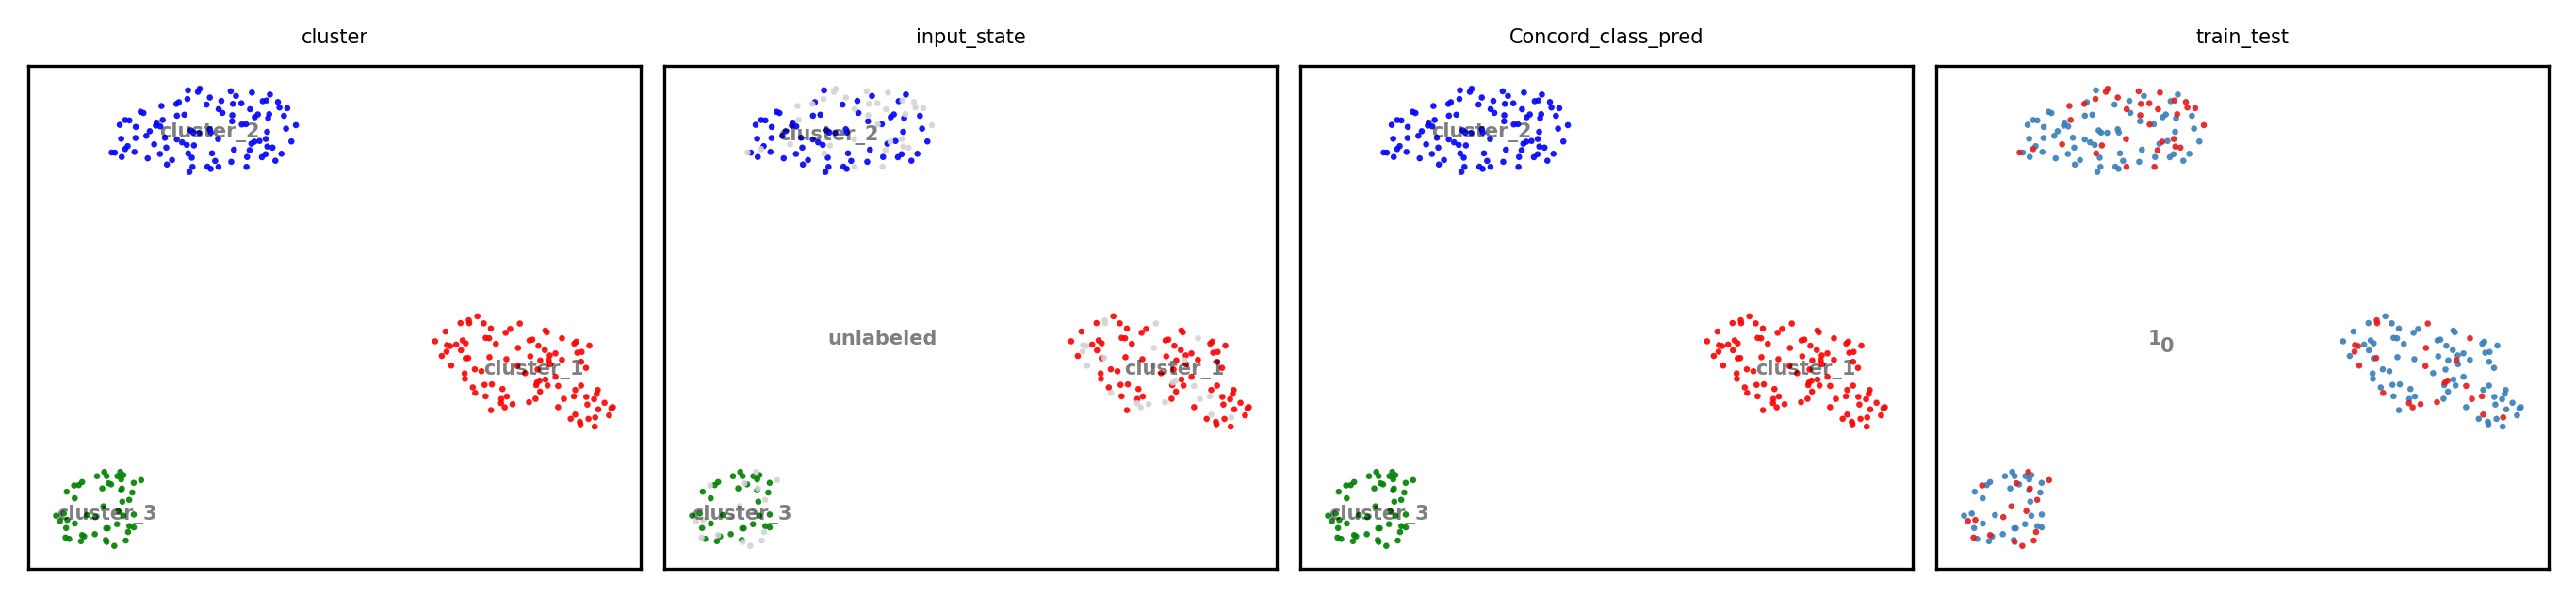

In [18]:
adata_merge = adata_train.concatenate(adata_pred, batch_key='train_test', index_unique=None)
ccd.ul.run_umap(adata_merge, source_key='Concord', result_key='Concord_UMAP_2D', n_components=2, n_neighbors=30, min_dist=0.5, metric='cosine', random_state=seed)

color_by = [state_key, 'input_state', 'Concord_class_pred', 'train_test']
show_basis = 'Concord_UMAP_2D'   
ccd.pl.plot_embedding(
    adata_merge, show_basis, color_by, figsize=(9,2), dpi=300, ncols=4, font_size=5, point_size=10, legend_loc='on data',
    pal=pal,
    save_path=save_dir / f"{show_basis}_{file_suffix}.png"
)
